In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "../road_dataset"
IMG_SIZE = 128

X = []
y_binary = []
y_multi = []

class_names = ['good', 'satisfactory', 'poor', 'very_poor']

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)

        # Binary label
        if class_name == "good":
            y_binary.append(0)   # No pothole
        else:
            y_binary.append(1)   # Pothole exists

        # Multi-class label
        if class_name != "good":
            if class_name == "satisfactory":
                y_multi.append(0)
            elif class_name == "poor":
                y_multi.append(1)
            else:
                y_multi.append(2)

X = np.array(X)
y_binary = np.array(y_binary)

# Multi only for pothole images
X_multi = X[y_binary == 1]
y_multi = to_categorical(y_multi, 3)

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_binary_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [3]:
def build_multi_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D(2,2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [5]:
fold = 1

for train_idx, val_idx in kfold.split(X):
    print(f"\nBinary Training Fold {fold}")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_binary[train_idx], y_binary[val_idx]

    model_bin = build_binary_model()

    model_bin.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=16
    )

    model_bin.save(f"binary_model_fold_{fold}.h5")

    fold += 1


Binary Training Fold 1


c:\Users\KIIT0001\anaconda3\envs\AP\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 154s 618ms/step - accuracy: 0.9322 - loss: 0.1754 - val_accuracy: 0.9703 - val_loss: 0.0849
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 213s 659ms/step - accuracy: 0.9620 - loss: 0.1020 - val_accuracy: 0.9815 - val_loss: 0.0612
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 39s 161ms/step - accuracy: 0.9725 - loss: 0.0746 - val_accuracy: 0.9795 - val_loss: 0.0463
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 149ms/step - accuracy: 0.9766 - loss: 0.0611 - val_accuracy: 0.9877 - val_loss: 0.0412
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 37s 150ms/step - accuracy: 0.9859 - loss: 0.0458 - val_accuracy: 0.9867 - val_loss: 0.0354
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 148ms/step - accuracy: 0.9805 - loss: 0.0560 - val_accuracy: 0.9877 - val_loss: 0.0391
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 38s 155ms/step - accuracy: 0.9849 - loss: 0.0494 - val_accuracy: 0.9867 - val_loss: 0.0398
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 131s 540ms/step - accuracy: 0.9900 - loss


Binary Training Fold 2
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 106s 409ms/step - accuracy: 0.9145 - loss: 0.2216 - val_accuracy: 0.9774 - val_loss: 0.0733
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 40s 165ms/step - accuracy: 0.9607 - loss: 0.1066 - val_accuracy: 0.9846 - val_loss: 0.0513
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 38s 154ms/step - accuracy: 0.9725 - loss: 0.0727 - val_accuracy: 0.9795 - val_loss: 0.0600
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 36s 149ms/step - accuracy: 0.9746 - loss: 0.0743 - val_accuracy: 0.9877 - val_loss: 0.0305
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 40s 166ms/step - accuracy: 0.9813 - loss: 0.0599 - val_accuracy: 0.9897 - val_loss: 0.0294
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 42s 170ms/step - accuracy: 0.9859 - loss: 0.0496 - val_accuracy: 0.9928 - val_loss: 0.0339
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 46s 187ms/step - accuracy: 0.9797 - loss: 0.0552 - val_accuracy: 0.9949 - val_loss: 0.0199
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 53s 218ms/step - a


Binary Training Fold 3
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 51s 183ms/step - accuracy: 0.9207 - loss: 0.1929 - val_accuracy: 0.9774 - val_loss: 0.0688
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 47s 190ms/step - accuracy: 0.9633 - loss: 0.0946 - val_accuracy: 0.9743 - val_loss: 0.0683
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 177ms/step - accuracy: 0.9697 - loss: 0.0820 - val_accuracy: 0.9795 - val_loss: 0.0450
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 174ms/step - accuracy: 0.9764 - loss: 0.0771 - val_accuracy: 0.9815 - val_loss: 0.0590
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 121s 250ms/step - accuracy: 0.9792 - loss: 0.0687 - val_accuracy: 0.9836 - val_loss: 0.0392
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 63s 259ms/step - accuracy: 0.9723 - loss: 0.0921 - val_accuracy: 0.9836 - val_loss: 0.0362
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 49s 199ms/step - accuracy: 0.9849 - loss: 0.0506 - val_accuracy: 0.9918 - val_loss: 0.0237
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - a


Binary Training Fold 4
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 45s 175ms/step - accuracy: 0.9412 - loss: 0.1674 - val_accuracy: 0.9641 - val_loss: 0.0883
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 43s 176ms/step - accuracy: 0.9779 - loss: 0.0718 - val_accuracy: 0.9723 - val_loss: 0.0656
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 93s 220ms/step - accuracy: 0.9826 - loss: 0.0613 - val_accuracy: 0.9815 - val_loss: 0.0769
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 62s 255ms/step - accuracy: 0.9733 - loss: 0.0793 - val_accuracy: 0.9692 - val_loss: 0.0787
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 59s 240ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9764 - val_loss: 0.0563
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 86s 351ms/step - accuracy: 0.9895 - loss: 0.0295 - val_accuracy: 0.9867 - val_loss: 0.0533
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 53s 216ms/step - accuracy: 0.9918 - loss: 0.0256 - val_accuracy: 0.9887 - val_loss: 0.0364
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 89s 367ms/step - ac


Binary Training Fold 5
Epoch 1/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 59s 224ms/step - accuracy: 0.9222 - loss: 0.2101 - val_accuracy: 0.9805 - val_loss: 0.0568
Epoch 2/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 50s 203ms/step - accuracy: 0.9533 - loss: 0.1154 - val_accuracy: 0.9733 - val_loss: 0.0652
Epoch 3/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 48s 196ms/step - accuracy: 0.9713 - loss: 0.0802 - val_accuracy: 0.9836 - val_loss: 0.0444
Epoch 4/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 49s 200ms/step - accuracy: 0.9715 - loss: 0.0856 - val_accuracy: 0.9856 - val_loss: 0.0429
Epoch 5/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 52s 213ms/step - accuracy: 0.9682 - loss: 0.0994 - val_accuracy: 0.9682 - val_loss: 0.0968
Epoch 6/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 2299s 9s/step - accuracy: 0.9731 - loss: 0.0748 - val_accuracy: 0.9887 - val_loss: 0.0287
Epoch 7/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 66s 269ms/step - accuracy: 0.9787 - loss: 0.0691 - val_accuracy: 0.9877 - val_loss: 0.0336
Epoch 8/10
244/244 ━━━━━━━━━━━━━━━━━━━━ 49s 200ms/step - acc

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [7]:
def get_callbacks(model_name, fold):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        ModelCheckpoint(
            filepath=f"{model_name}_fold_{fold}.h5",
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        )
    ]

In [9]:
fold = 1

for train_idx, val_idx in kfold.split(X_multi):
    print(f"\n🔹 Multi-Class Training Fold {fold}")

    X_train, X_val = X_multi[train_idx], X_multi[val_idx]
    y_train, y_val = y_multi[train_idx], y_multi[val_idx]

    model_multi = build_multi_model()

    callbacks = get_callbacks("multi_model", fold)

    model_multi.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=16,
        callbacks=callbacks
    )

    fold += 1


🔹 Multi-Class Training Fold 1
Epoch 1/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7078 - loss: 0.7552
Epoch 1: val_accuracy improved from None to 0.88830, saving model to multi_model_fold_1.h5



Epoch 1: finished saving model to multi_model_fold_1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 33s 164ms/step - accuracy: 0.7895 - loss: 0.5344 - val_accuracy: 0.8883 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8693 - loss: 0.3095
Epoch 2: val_accuracy did not improve from 0.88830
190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 147ms/step - accuracy: 0.8727 - loss: 0.3028 - val_accuracy: 0.8541 - val_loss: 0.3640 - learning_rate: 0.0010
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8818 - loss: 0.2922
Epoch 3: val_accuracy improved from 0.88830 to 0.90802, saving model to multi_model_fold_1.h5



Epoch 3: finished saving model to multi_model_fold_1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.9016 - loss: 0.2507 - val_accuracy: 0.9080 - val_loss: 0.2346 - learning_rate: 0.0010
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9095 - loss: 0.2144
Epoch 4: val_accuracy improved from 0.90802 to 0.91721, saving model to multi_model_fold_1.h5



Epoch 4: finished saving model to multi_model_fold_1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.9141 - loss: 0.2074 - val_accuracy: 0.9172 - val_loss: 0.2040 - learning_rate: 0.0010
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9269 - loss: 0.1799
Epoch 5: val_accuracy improved from 0.91721 to 0.92641, saving model to multi_model_fold_1.h5



Epoch 5: finished saving model to multi_model_fold_1.h5
190/190 ━━━━━━━━━━━━━━━━━━━━ 30s 156ms/step - accuracy: 0.9253 - loss: 0.1796 - val_accuracy: 0.9264 - val_loss: 0.1975 - learning_rate: 0.0010
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9465 - loss: 0.1348
Epoch 6: val_accuracy did not improve from 0.92641
190/190 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.9461 - loss: 0.1442 - val_accuracy: 0.9238 - val_loss: 0.1953 - learning_rate: 0.0010
Epoch 7/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9444 - loss: 0.1430
Epoch 7: val_accuracy did not improve from 0.92641
190/190 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.9382 - loss: 0.1470 - val_accuracy: 0.9251 - val_loss: 0.2079 - learning_rate: 0.0010
Epoch 8/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9545 - loss: 0.1122
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 8: val_accuracy improved from 0.92641 to 0.93035, saving model

...


Epoch 4: finished saving model to multi_model_fold_5.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 37s 193ms/step - accuracy: 0.9188 - loss: 0.2122 - val_accuracy: 0.9105 - val_loss: 0.2033 - learning_rate: 0.0010
Epoch 5/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9257 - loss: 0.1809
Epoch 5: val_accuracy improved from 0.91053 to 0.93289, saving model to multi_model_fold_5.h5



Epoch 5: finished saving model to multi_model_fold_5.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 33s 171ms/step - accuracy: 0.9214 - loss: 0.1832 - val_accuracy: 0.9329 - val_loss: 0.1738 - learning_rate: 0.0010
Epoch 6/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9375 - loss: 0.1736
Epoch 6: val_accuracy did not improve from 0.93289
191/191 ━━━━━━━━━━━━━━━━━━━━ 46s 241ms/step - accuracy: 0.9365 - loss: 0.1654 - val_accuracy: 0.9276 - val_loss: 0.1766 - learning_rate: 0.0010
Epoch 7/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9391 - loss: 0.1391
Epoch 7: val_accuracy improved from 0.93289 to 0.93947, saving model to multi_model_fold_5.h5



Epoch 7: finished saving model to multi_model_fold_5.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 42s 222ms/step - accuracy: 0.9454 - loss: 0.1399 - val_accuracy: 0.9395 - val_loss: 0.1687 - learning_rate: 0.0010
Epoch 8/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9582 - loss: 0.1193
Epoch 8: val_accuracy improved from 0.93947 to 0.94342, saving model to multi_model_fold_5.h5



Epoch 8: finished saving model to multi_model_fold_5.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 39s 203ms/step - accuracy: 0.9599 - loss: 0.1076 - val_accuracy: 0.9434 - val_loss: 0.1869 - learning_rate: 0.0010
Epoch 9/20
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.9485 - loss: 0.1136
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 9: val_accuracy did not improve from 0.94342
191/191 ━━━━━━━━━━━━━━━━━━━━ 40s 208ms/step - accuracy: 0.9536 - loss: 0.1117 - val_accuracy: 0.9395 - val_loss: 0.1820 - learning_rate: 0.0010
Epoch 10/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9735 - loss: 0.0838
Epoch 10: val_accuracy improved from 0.94342 to 0.94605, saving model to multi_model_fold_5.h5



Epoch 10: finished saving model to multi_model_fold_5.h5
191/191 ━━━━━━━━━━━━━━━━━━━━ 50s 261ms/step - accuracy: 0.9763 - loss: 0.0701 - val_accuracy: 0.9461 - val_loss: 0.1844 - learning_rate: 3.0000e-04
Epoch 11/20
190/191 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9800 - loss: 0.0528
Epoch 11: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 11: val_accuracy did not improve from 0.94605
191/191 ━━━━━━━━━━━━━━━━━━━━ 38s 198ms/step - accuracy: 0.9809 - loss: 0.0536 - val_accuracy: 0.9408 - val_loss: 0.2140 - learning_rate: 3.0000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 7.


In [11]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    # Use SAME validation split logic
    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


Fold 1 Accuracy: 0.9928

Evaluating Fold 2


Fold 2 Accuracy: 0.9928

Evaluating Fold 3


Fold 3 Accuracy: 0.9887

Evaluating Fold 4


Fold 4 Accuracy: 0.9846

Evaluating Fold 5
Fold 5 Accuracy: 0.9887


In [12]:
import numpy as np

print("\nFinal Cross-Validation Accuracy:")
print("Mean Accuracy:", np.mean(val_accuracies))
print("Std Dev:", np.std(val_accuracies))


Final Cross-Validation Accuracy:
Mean Accuracy: 0.9895291924476624
Std Dev: 0.003074811800781626


In [14]:
from tensorflow.keras.models import load_model
import numpy as np

val_accuracies_multi = []

for fold in range(1, 6):
    print(f"\nEvaluating Multi-Class Fold {fold}")

    model = load_model(f"multi_model_fold_{fold}.h5")

    # Get same validation split
    _, val_idx = list(kfold.split(X_multi))[fold-1]
    
    X_val = X_multi[val_idx]
    y_val = y_multi[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies_multi.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Multi-Class Fold 1


Fold 1 Accuracy: 0.9396

Evaluating Multi-Class Fold 2


Fold 2 Accuracy: 0.9592

Evaluating Multi-Class Fold 3
Fold 3 Accuracy: 0.9539

Evaluating Multi-Class Fold 4


Fold 4 Accuracy: 0.9408

Evaluating Multi-Class Fold 5
Fold 5 Accuracy: 0.9461


In [15]:
print("\nFinal Multi-Class Cross-Validation Accuracy:")
print("Mean Accuracy:", np.mean(val_accuracies_multi))
print("Std Dev:", np.std(val_accuracies_multi))


Final Multi-Class Cross-Validation Accuracy:
Mean Accuracy: 0.9479106307029724
Std Dev: 0.007591303862179161


In [19]:
import matplotlib.pyplot as plt

In [22]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


Fold 1 Accuracy: 0.9928

Evaluating Fold 2


Fold 2 Accuracy: 0.9928

Evaluating Fold 3


Fold 3 Accuracy: 0.9887

Evaluating Fold 4


Fold 4 Accuracy: 0.9846

Evaluating Fold 5
Fold 5 Accuracy: 0.9887


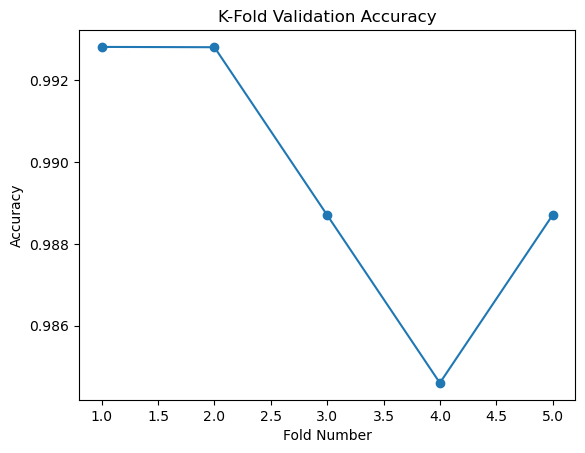

In [23]:
import matplotlib.pyplot as plt

folds = list(range(1, len(val_accuracies)+1))

plt.figure()
plt.plot(folds, val_accuracies, marker='o')

plt.title('K-Fold Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.show()

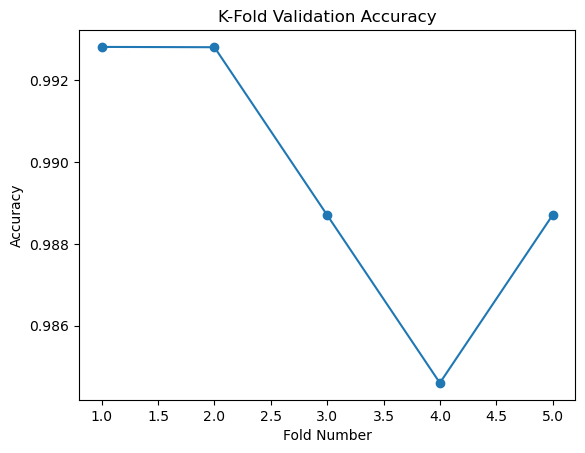

In [24]:
import matplotlib.pyplot as plt

folds = list(range(1, len(val_accuracies)+1))

plt.figure()
plt.plot(folds, val_accuracies, marker='o')

plt.title('K-Fold Validation Accuracy')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')

plt.show()

In [25]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    val_accuracies.append(acc)

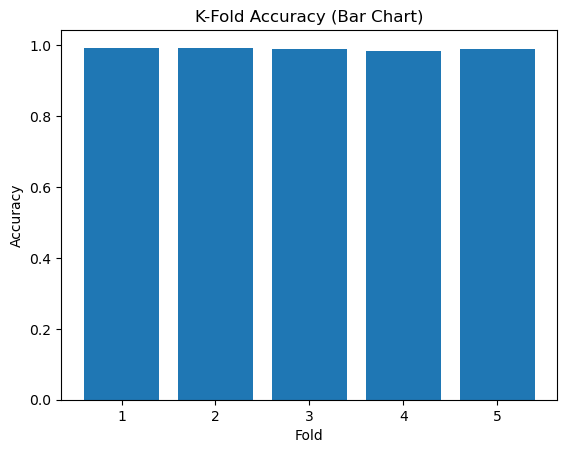

In [26]:
plt.figure()
plt.bar(folds, val_accuracies)

plt.title('K-Fold Accuracy (Bar Chart)')
plt.xlabel('Fold')
plt.ylabel('Accuracy')

plt.show()

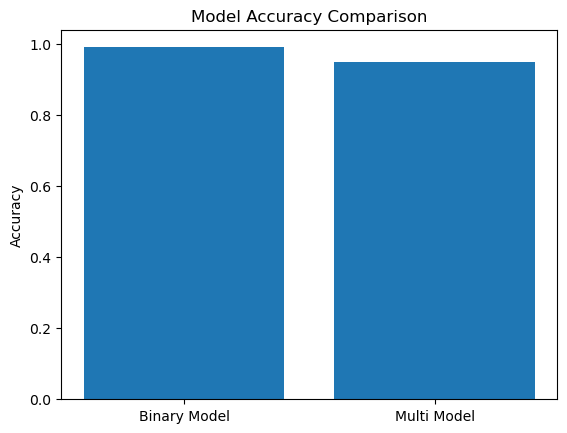

In [27]:
labels = ['Binary Model', 'Multi Model']
accuracies = [np.mean(val_accuracies), np.mean(val_accuracies_multi)]

plt.figure()
plt.bar(labels, accuracies)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')

plt.show()

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step


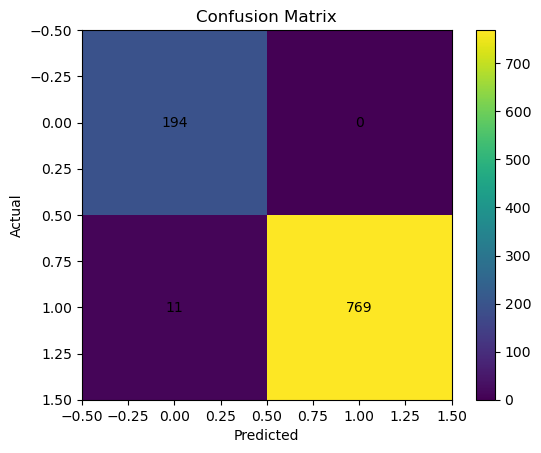

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_val)
y_pred = (y_pred > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred)

plt.figure()
plt.imshow(cm)
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [6]:
from sklearn.model_selection import KFold

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "../road_dataset"
IMG_SIZE = 128

X = []
y_binary = []

class_names = ['good', 'satisfactory', 'poor', 'very_poor']

for class_name in class_names:
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X.append(img)

        if class_name == "good":
            y_binary.append(0)
        else:
            y_binary.append(1)

X = np.array(X)
y_binary = np.array(y_binary)

In [2]:
from tensorflow.keras.models import load_model

val_accuracies = []

for fold in range(1, 6):
    print(f"\nEvaluating Fold {fold}")

    model = load_model(f"binary_model_fold_{fold}.h5")

    _, val_idx = list(kfold.split(X))[fold-1]
    X_val = X[val_idx]
    y_val = y_binary[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Fold 1


NameError: name 'kfold' is not defined

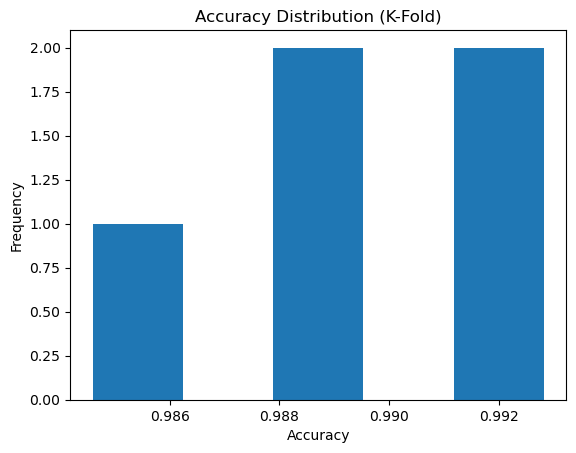

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(val_accuracies, bins=5)

plt.title("Accuracy Distribution (K-Fold)")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")

plt.show()

In [14]:
print("Binary:", val_accuracies)
print("Multi:", val_accuracies_multi)

Binary: [0.9928205013275146, 0.9928131699562073, 0.9887063503265381, 0.9845995903015137, 0.9887063503265381]
Multi: []


In [1]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical

DATASET_PATH = "../road_dataset"
IMG_SIZE = 128

X_multi = []
y_multi = []

class_names = ['satisfactory', 'poor', 'very_poor']

for label, class_name in enumerate(class_names):
    class_path = os.path.join(DATASET_PATH, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0

        X_multi.append(img)
        y_multi.append(label)

X_multi = np.array(X_multi)
y_multi = to_categorical(y_multi, num_classes=3)

In [18]:
from tensorflow.keras.models import load_model
import numpy as np

val_accuracies_multi = []

for fold in range(1, 6):
    print(f"\nEvaluating Multi-Class Fold {fold}")

    model = load_model(f"multi_model_fold_{fold}.h5")

    # Get same validation split
    _, val_idx = list(kfold.split(X_multi))[fold-1]
    
    X_val = X_multi[val_idx]
    y_val = y_multi[val_idx]

    loss, acc = model.evaluate(X_val, y_val, verbose=0)

    val_accuracies_multi.append(acc)

    print(f"Fold {fold} Accuracy: {acc:.4f}")


Evaluating Multi-Class Fold 1


Fold 1 Accuracy: 0.9396

Evaluating Multi-Class Fold 2


Fold 2 Accuracy: 0.9592

Evaluating Multi-Class Fold 3


Fold 3 Accuracy: 0.9539

Evaluating Multi-Class Fold 4


Fold 4 Accuracy: 0.9408

Evaluating Multi-Class Fold 5
Fold 5 Accuracy: 0.9461


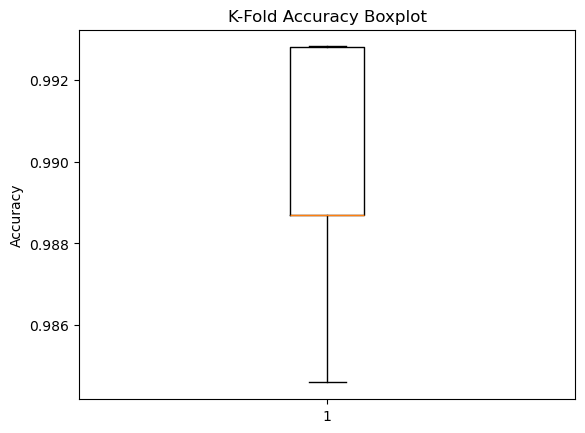

In [19]:
plt.figure()
plt.boxplot(val_accuracies)

plt.title("K-Fold Accuracy Boxplot")
plt.ylabel("Accuracy")

plt.show()

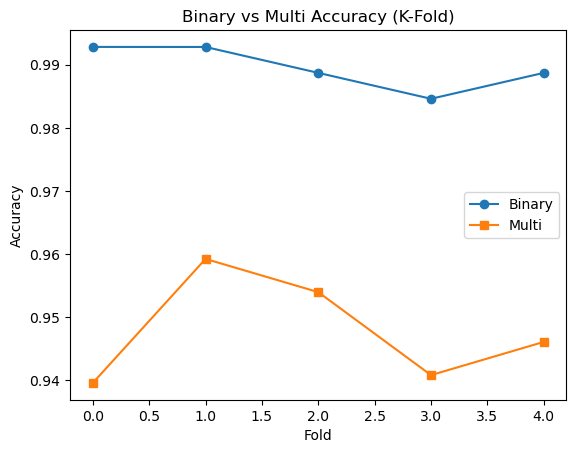

In [20]:
plt.figure()

plt.plot(val_accuracies, marker='o', label='Binary')
plt.plot(val_accuracies_multi, marker='s', label='Multi')

plt.title("Binary vs Multi Accuracy (K-Fold)")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.legend()

plt.show()